In [1]:
!pip install yfinance

   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ------------------ --------------------- 0.8/1.7 MB 6.7 MB/s eta 0:00:01
   ---------------------------------------- 1.7/1.7 MB 4.3 MB/s  0:00:00

   ----------------------------------------  0/14 [pytz]
   ----------------------------------------  0/14 [pytz]
   -- -------------------------------------  1/14 [peewee]
   -------- -------------------------------  3/14 [websockets]
   -------- -------------------------------  3/14 [websockets]
   ----------------- ----------------------  6/14 [protobuf]
   ----------------- ----------------------  6/14 [protobuf]
   ---------------------- -----------------  8/14 [markdown-it-py]
   ------------------------- --------------  9/14 [cffi]
   ------------------------------- -------- 11/14 [rich]
   ------------------------------- -------- 11/14 [rich]
   ------------------------------- -------- 11/14 [rich]
   ---------------------------------- ----- 12/14 [curl_cffi]
   

In [1]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt 

reliance = yf.download("reliance.ns",period="1y")
tcs=yf.download("tcs.ns",period="1y")
reliance.head()
tcs.head()

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,TCS.NS,TCS.NS,TCS.NS,TCS.NS,TCS.NS
Date,,,,,
2025-06-26,3311.496826,3320.733239,3286.000091,3314.383249,2879106
2025-06-27,3310.823730,3335.165712,3301.106012,3324.197397,1778433
2025-06-30,3330.931885,3333.721999,3300.143375,3309.668476,1468351
2025-07-01,3299.854736,3353.061177,3284.268100,3324.196949,2375183
2025-07-02,3293.697266,3357.775714,3290.522153,3355.177980,3090585


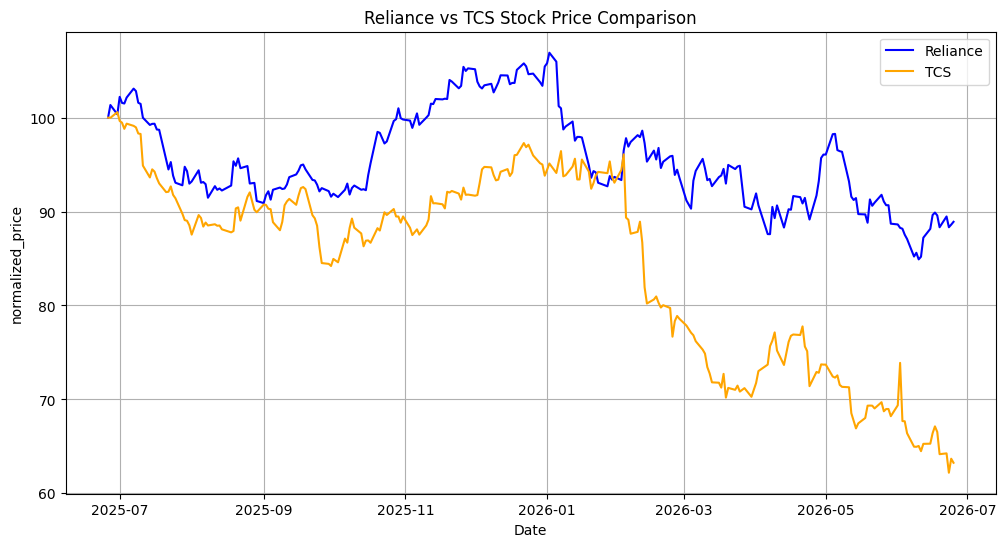

In [2]:
reliance_normalized=(reliance['Close']/reliance['Close'].iloc[0])*100
tcs_normalized=(tcs['Close']/tcs['Close'].iloc[0])*100
plt.figure(figsize=(12,6))
plt.plot(reliance_normalized,label='Reliance',color='blue')
plt.plot(tcs_normalized,label='TCS',color='orange')
plt.xlabel("Date")
plt.ylabel("normalized_price")
plt.title("Reliance vs TCS Stock Price Comparison")
plt.legend()
plt.grid(True)
plt.show()

tcs daily return: Ticker
TCS.NS   -0.00172
dtype: float64
TCS volatility: Ticker
TCS.NS    0.015744
dtype: float64
Reliance daily return: Ticker
RELIANCE.NS   -0.000393
dtype: float64
Reliance volatility: Ticker
RELIANCE.NS    0.0127
dtype: float64


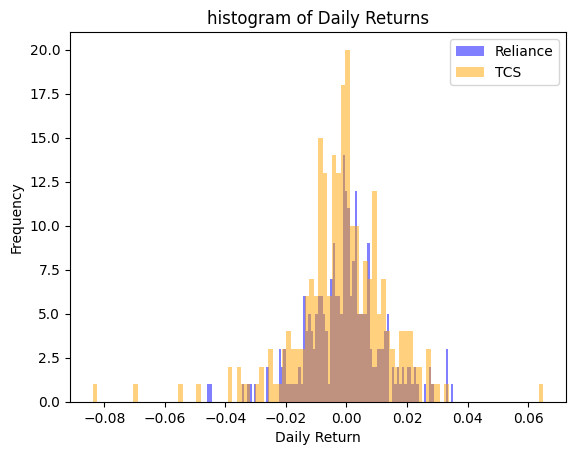

In [3]:
reliance_return=reliance['Close'].pct_change().dropna()
tc_return=tcs['Close'].pct_change().dropna()
print("tcs daily return:",tc_return.mean())
print("TCS volatility:",tc_return.std())
print("Reliance daily return:",reliance_return.mean())
print("Reliance volatility:",reliance_return.std())
plt.hist(reliance_return,bins=100,alpha=0.5,label='Reliance',color='blue')
plt.hist(tc_return,bins=100,alpha=0.5,label='TCS',color='orange')
plt.xlabel('Daily Return')
plt.ylabel('Frequency')
plt.title("histogram of Daily Returns")
plt.legend()
plt.show()


In [4]:
returns = pd.DataFrame({'Reliance': reliance_return.squeeze(), 'TCS': tc_return.squeeze()})

In [27]:
returns.corr()

,Reliance,TCS
Reliance,1.000000,0.205633
TCS,0.205633,1.000000


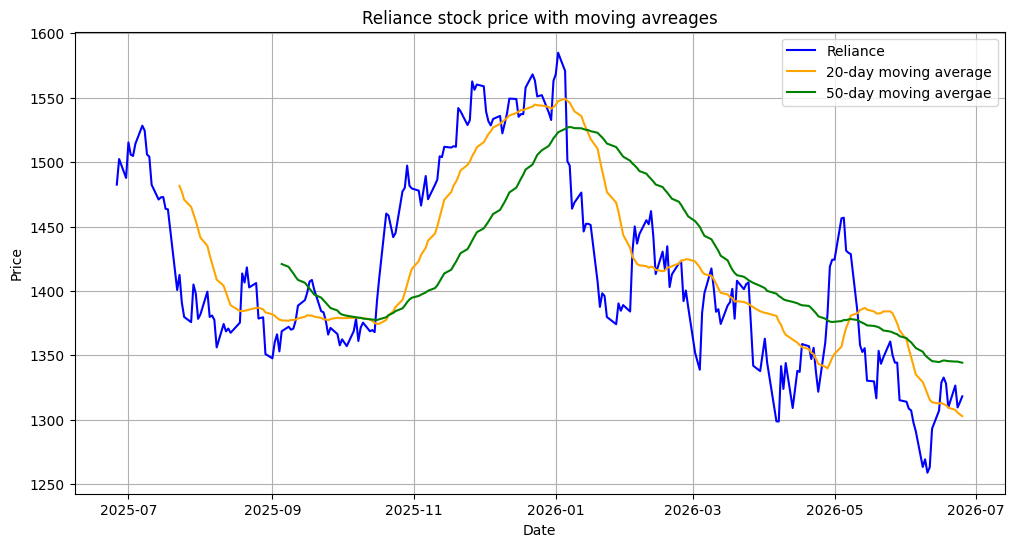

In [8]:
reliance_moving_avg20=reliance['Close'].rolling(window=20).mean()
reliance_moving_avg50=reliance['Close'].rolling(window=50).mean()
plt.figure(figsize=(12,6))
plt.plot(reliance['Close'],label='Reliance',color='blue')
plt.plot(reliance_moving_avg20,label='20-day moving average',color='orange')
plt.plot(reliance_moving_avg50,label='50-day moving avergae',color='green')
plt.xlabel('Date')
plt.ylabel('Price')
plt.title('Reliance stock price with moving avreages')
plt.legend()
plt.grid(True)
plt.show()


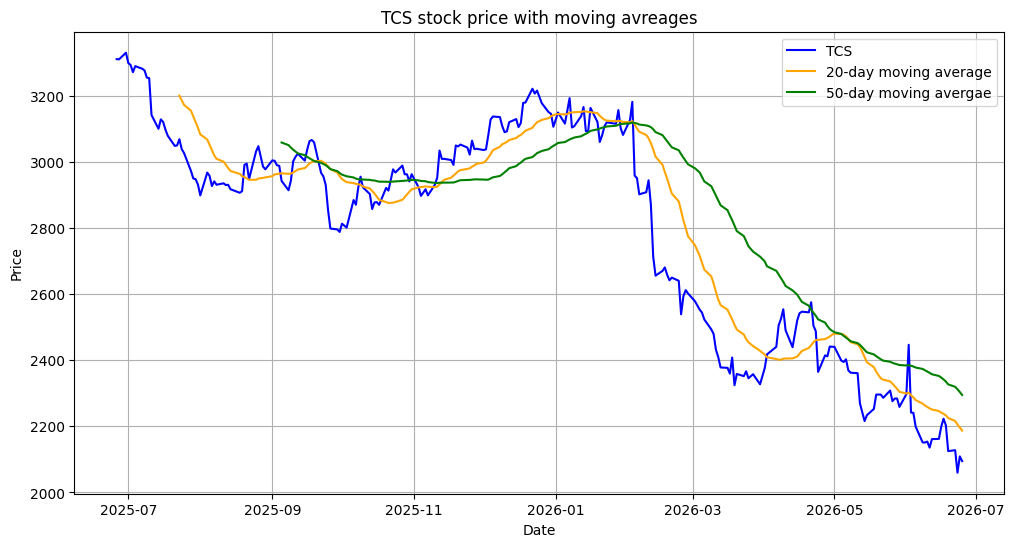

In [11]:
tcs_moving_avg20=tcs['Close'].rolling(window=20).mean()
tcs_moving_avg50=tcs['Close'].rolling(window=50).mean()
plt.figure(figsize=(12,6))
plt.plot(tcs['Close'],label='TCS',color='blue')
plt.plot(tcs_moving_avg20,label='20-day moving average',color='orange')
plt.plot(tcs_moving_avg50,label='50-day moving avergae',color='green')
plt.xlabel('Date')
plt.ylabel('Price')
plt.title('TCS stock price with moving avreages')
plt.legend()
plt.grid(True)
plt.show()
